In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(
    '../data/logins.csv',
    parse_dates=['timestamp_login']
)

#Lendo as principais informações dos dados
print(df.head())
print(df.shape)
print(df.dtypes)
df.info()

print(df.describe())
colunas_numericas = [
    'tentativas_falhas',
    'distancia_km',
    'tempo_desde_ultimo_login'
]

print(
    df[colunas_numericas].describe()
)

In [ ]:
#Fazendo gráficos para entender melhor seus parametros
contagem_falhas = (df['tentativas_falhas'].value_counts().sort_index())
plt.bar(contagem_falhas.index, contagem_falhas.values)
plt.xlabel('Tentativas falhas')
plt.ylabel('Quantidade de logins')
plt.title('Distribuição das tentativas falhas')
plt.show()

plt.hist(df['distancia_km'], bins=50)
plt.xlabel('Distância (km)')
plt.ylabel('Quantidade de logins')
plt.title('Distribuição das distâncias dos logins')
plt.show()

df['distancia_log'] = np.log1p(df['distancia_km'])
plt.hist(df['distancia_log'], bins=50)
plt.xlabel('Log da distância')
plt.ylabel('Quantidade de logins')
plt.title('Distribuição logarítmica das distâncias')
plt.show()

contagem_target = (df['login_suspeito'].value_counts().sort_index())
plt.bar(contagem_target.index, contagem_target.values)
plt.xticks([0, 1], ['Normal', 'Suspeito'])
plt.xlabel('Classificação')
plt.ylabel('Quantidade de logins')
plt.title('Distribuição dos logins normais e suspeitos')
print(df['login_suspeito'].value_counts(normalize=True)* 100)


In [ ]:
#Tirando conclusões do peso de parametros para um login suspeito
df.groupby('login_suspeito')['tentativas_falhas'].mean()
df.groupby('login_suspeito')['tentativas_falhas'].median()
df.groupby('login_suspeito')['tentativas_falhas'].describe()

taxa_suspeitos_por_falhas = (
    df.groupby('tentativas_falhas')['login_suspeito']
    .mean()
    * 100
)
print(taxa_suspeitos_por_falhas)
plt.bar(taxa_suspeitos_por_falhas.index, taxa_suspeitos_por_falhas.values)
plt.xlabel('Tentativas falhas')
plt.ylabel('Logins suspeitos (%)')
plt.title('Taxa de logins suspeitos por tentativas falhas')
plt.show()

In [ ]:
taxa_suspeitos_dispositivo = (df.groupby('novo_dispositivo')['login_suspeito'].mean()* 100)
print(taxa_suspeitos_dispositivo)
plt.bar(taxa_suspeitos_dispositivo.index, taxa_suspeitos_dispositivo.values)
plt.xticks([0, 1], ['Conhecido', 'Novo'])
plt.xlabel('Novo dispositivo')
plt.ylabel('Logins suspeitos (%)')
plt.title('Taxa de logins suspeitos por novo dispositivo')
plt.show()

In [ ]:
taxa_suspeitos_ip = (df.groupby('novo_ip')['login_suspeito'].mean()* 100)
print(taxa_suspeitos_ip)
plt.bar(taxa_suspeitos_ip.index, taxa_suspeitos_ip.values)
plt.xticks([0, 1], ['Conhecido', 'Novo'])
plt.xlabel('Novo ip')
plt.ylabel('Logins suspeitos (%)')
plt.title('Taxa de logins suspeitos por novo ip')
plt.show()

In [ ]:
taxa_suspeitos_vpn = (df.groupby('vpn_proxy')['login_suspeito'].mean()* 100)
print(taxa_suspeitos_vpn)
plt.bar(taxa_suspeitos_vpn.index, taxa_suspeitos_vpn.values)
plt.xticks([0, 1], ['Sem', 'Com'])
plt.xlabel('Usando vpn')
plt.ylabel('Logins suspeitos (%)')
plt.title('Taxa de logins suspeitos por vpn')
plt.show()

In [ ]:
taxa_suspeitos_pais = (df.groupby('pais_diferente')['login_suspeito'].mean()* 100)
print(taxa_suspeitos_pais)
plt.bar(taxa_suspeitos_pais.index, taxa_suspeitos_pais.values)
plt.xticks([0, 1], ['Mesmo país', 'Outro país'])
plt.xlabel('País diferente')
plt.ylabel('Logins suspeitos (%)')
plt.title('Taxa de logins suspeitos por pais diferente')
plt.show()

In [ ]:
print(df.groupby('login_suspeito')['distancia_log'].describe())
plt.boxplot(
    [
        df[df['login_suspeito'] == 0]['distancia_log'],
        df[df['login_suspeito'] == 1]['distancia_log']
    ],
    tick_labels=['Normal', 'Suspeito']
)

plt.xlabel('Classificação')
plt.ylabel('Log da distância')
plt.title('Distância dos logins por classificação')
plt.show()

In [ ]:
df.groupby('login_suspeito')['tempo_desde_ultimo_login'].describe()
df['tempo_log'] = np.log1p(
    df['tempo_desde_ultimo_login']
)
df.groupby('login_suspeito')['tempo_log'].describe()

df['hora_login'] = df['timestamp_login'].dt.hour
taxa_suspeitos_hora = (df.groupby('hora_login')['login_suspeito'].mean()* 100)
print(taxa_suspeitos_hora)

plt.plot(
    taxa_suspeitos_hora.index,
    taxa_suspeitos_hora.values,
    marker='o'
)
plt.xlabel('Hora do login')
plt.ylabel('Logins suspeitos (%)')
plt.title('Taxa de logins suspeitos por hora')
plt.xticks(range(24))
plt.show()

df['login_madrugada'] = (
    (df['hora_login'] >= 0) &
    (df['hora_login'] <= 5)
).astype(int)
taxa_madrugada = (
    df.groupby('login_madrugada')['login_suspeito']
    .mean()
    * 100
)
print(taxa_madrugada)

correlacao = df.corr(numeric_only=True)
print(correlacao)
print(
    correlacao['login_suspeito']
    .sort_values(ascending=False)
)

correlacao_target = (
    correlacao['login_suspeito']
    .sort_values(ascending=False)
)
print(correlacao_target.to_string())

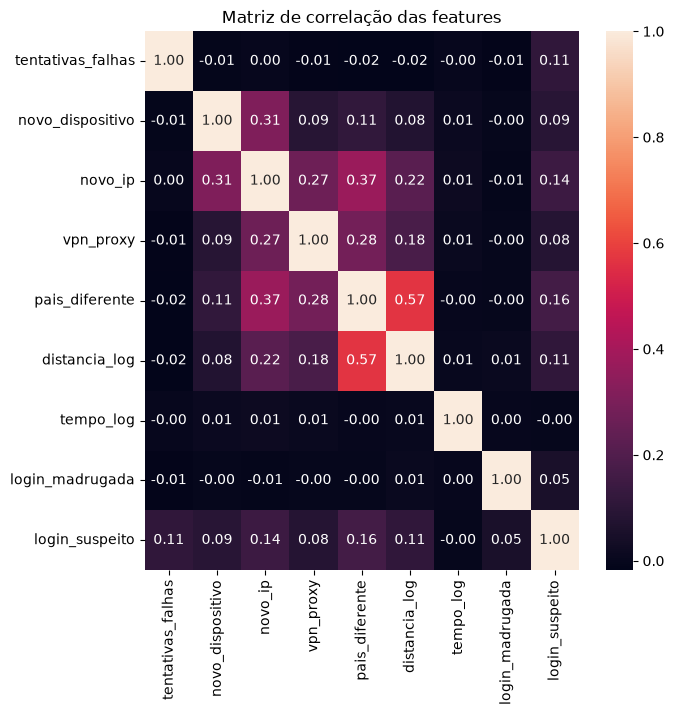

In [30]:
import seaborn as sns
colunas_correlacao = [
    'tentativas_falhas',
    'novo_dispositivo',
    'novo_ip',
    'vpn_proxy',
    'pais_diferente',
    'distancia_log',
    'tempo_log',
    'login_madrugada',
    'login_suspeito'
]
matriz_correlacao = df[colunas_correlacao].corr()
plt.figure(figsize=(7, 7))
sns.heatmap(matriz_correlacao, annot=True, fmt='.2f')
plt.title('Matriz de correlação das features')
plt.show()

In [3]:
features = [
'tentativas_falhas',
'novo_dispositivo',
'novo_ip',
'vpn_proxy',
'pais_diferente',
'distancia_log',
'tempo_log',
'primeiro_login',
'login_madrugada'
]

x = df[features]
y = df['login_suspeito']

print(x.head())
print(x.shape)

print(y.head())
print(y.shape)

NameError: name 'df' is not defined